SMART HR PROMOTION DASHBOARD - HYBRID SYSTEM
Random Forest + MCDM (SAW) untuk Employee Promotion

1. DATA INGESTION
Shape Train: (54808, 13)
Shape Test : (23490, 12)

Target Distribution (Train):
is_promoted
0    50140
1     4668
Name: count, dtype: int64

Proporsi Promosi: 8.52% (IMBALANCED!)

2. PREPROCESSING - HANDLING MISSING VALUES
Missing values sebelum handling: Train=6533, Test=2846
Missing values setelah handling: Train=0, Test=0

3. FEATURE ENGINEERING
New features created:
  - total_training_score (avg_training_score * no_of_trainings)
  - experience_ratio (length_of_service / age)
  - rating_award_interaction (previous_year_rating * awards_won?)

4. ENCODING CATEGORICAL VARIABLES
  Encoded department: {'Analytics': 0, 'Finance': 1, 'HR': 2, 'Legal': 3, 'Operations': 4, 'Procurement': 5, 'R&D': 6, 'Sales & Marketing': 7, 'Technology': 8}
  Encoded education: {"Bachelor's": 0, 'Below Secondary': 1, "Master's & above": 2}
  Encoded gender: {'f': 0, 'm': 1}

Final features: ['d

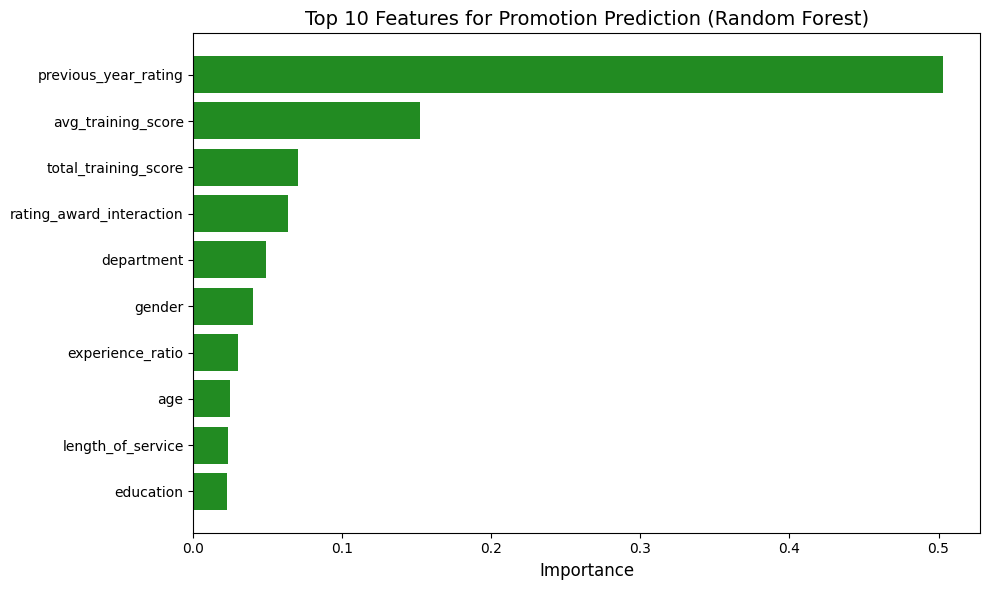


9. SHAP ANALYSIS - Model Transparency
(Sesuai soal poin 5: melihat fitur apa yang membuat karyawan diprediksi layak promosi)


<Figure size 1200x800 with 0 Axes>

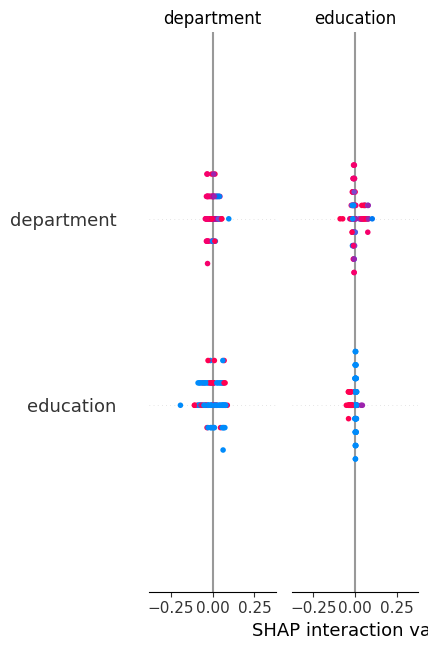


SHAP analysis completed - Plot saved as 'shap_analysis.png'

10. PREDIKSI PROBABILITAS PROMOSI
Test Set Results:
  Total candidates: 23490
  Predicted as promoted: 3211
  Average promotion probability: 0.3089
  Min probability: 0.0110
  Max probability: 0.9971

11. MCDM - DECISION MATRIX DESIGN (SAW METHOD)
(Sesuai soal: menyandingkan Probabilitas ML dengan kriteria statis)

MCDM Criteria and AHP Weights:
  promotion_prob: 0.35
  previous_year_rating: 0.15
  awards_won?: 0.1
  avg_training_score: 0.1
  length_of_service: 0.2
  no_of_trainings: 0.1

Decision Matrix Shape: (10, 6)
Alternatives: ['Emp_58638', 'Emp_43287', 'Emp_2030', 'Emp_64372', 'Emp_35037', 'Emp_77524', 'Emp_36434', 'Emp_15869', 'Emp_42224', 'Emp_78043']

12. NORMALISASI MATRIKS (SAW METHOD)

Normalized Decision Matrix (0-1 scale):
           previous_year_rating  awards_won?  avg_training_score  length_of_service  no_of_trainings  promotion_prob
Emp_58638                   0.6            0              0.6627         

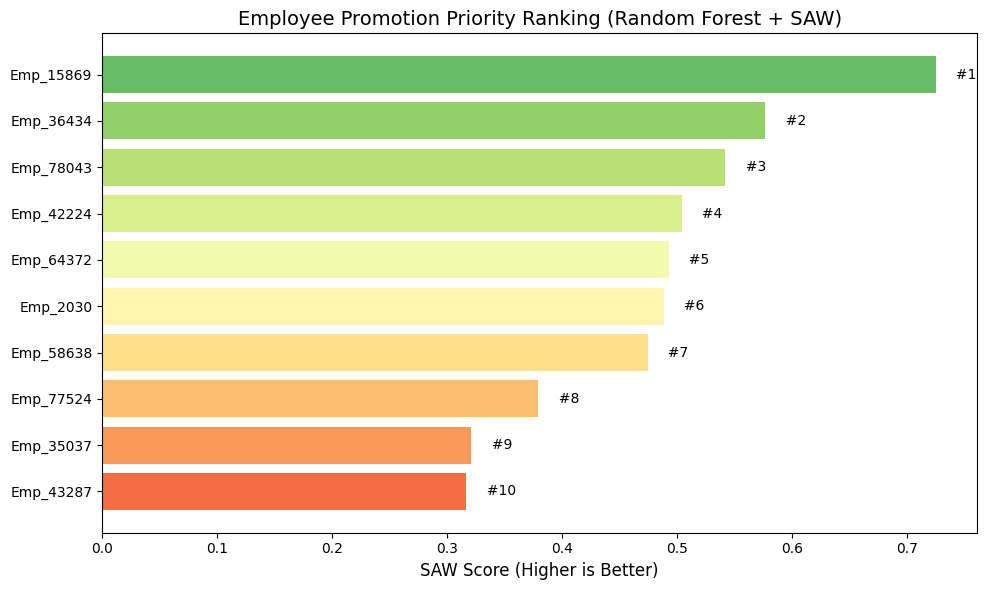


14. DECISION MATRIX (Original Values)
           previous_year_rating  awards_won?  avg_training_score  length_of_service  no_of_trainings ML_Probability
Emp_58638                   3.0            0                  55                  9                1         28.32%
Emp_43287                   2.0            0                  47                  8                1          7.24%
Emp_2030                    3.0            0                  71                  4                1         41.76%
Emp_64372                   3.0            0                  81                  1                1         48.91%
Emp_35037                   2.0            0                  77                  4                1         12.37%
Emp_77524                   4.0            0                  52                  3                1         21.04%
Emp_36434                   5.0            0                  48                  3                1         56.02%
Emp_15869                   5.0  

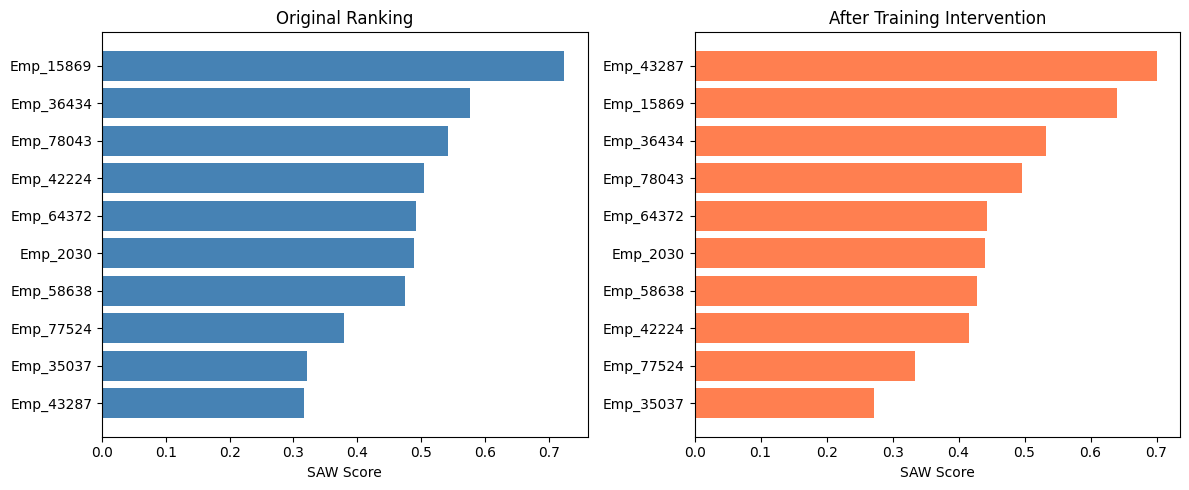


16. WHAT-IF ANALYSIS - SKENARIO 2: PENGHARGAAN

Skenario: Memberikan penghargaan kepada Emp_15869
  Current awards_won?: 0
  Current previous_year_rating: 5.0

Ranking Change After Award Recognition:
             Rank  Rank_new  Rank_Change
Alternative                             
Emp_15869       1         1            0
Emp_36434       2         2            0
Emp_78043       3         3            0
Emp_42224       4         4            0
Emp_64372       5         5            0

17. SAVING RESULTS
Saved: submission_hybrid.csv
Saved: promotion_ranking.csv
Saved: decision_matrix.csv
Saved: feature_importance.csv

SIMULATION COMPLETE - HYBRID SYSTEM SUMMARY

HASIL SIMULASI HYBRID (Random Forest + SAW):
-------------------------------------------------------------------
1. MODEL KLASIFIKASI (Random Forest):
   - F1-Score : 0.3551
   - ROC-AUC  : 0.7657

2. DATA BALANCING:
   - SMOTE diterapkan karena data tidak seimbang (8.52% promosi)

3. FEATURE IMPORTANCE TERTOP:
   - previous_year

In [2]:
# ============================================
# MATERI 5 - KASUS 3: EMPLOYEE PROMOTION
# SISTEM HIBRIDA RANDOM FOREST + MCDM (SAW)
# MENGGUNAKAN FILE TRAIN.CSV DAN TEST.CSV ASLI
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Untuk SHAP (opsional - sesuai soal poin 5)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("INFO: SHAP tidak tersedia. Install dengan: pip install shap\n")

print("="*70)
print("SMART HR PROMOTION DASHBOARD - HYBRID SYSTEM")
print("Random Forest + MCDM (SAW) untuk Employee Promotion")
print("="*70)

# ============================================
# 1. LOAD DATASET (DATA INGESTION)
# ============================================
print("\n" + "="*60)
print("1. DATA INGESTION")
print("="*60)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Shape Train: {train.shape}")
print(f"Shape Test : {test.shape}")
print(f"\nTarget Distribution (Train):")
print(train['is_promoted'].value_counts())
print(f"\nProporsi Promosi: {train['is_promoted'].mean()*100:.2f}% (IMBALANCED!)")

# ============================================
# 2. PREPROCESSING - HANDLE MISSING VALUES
# ============================================
print("\n" + "="*60)
print("2. PREPROCESSING - HANDLING MISSING VALUES")
print("="*60)

print(f"Missing values sebelum handling: Train={train.isnull().sum().sum()}, Test={test.isnull().sum().sum()}")

# Handle missing values
train['education'] = train['education'].fillna(train['education'].mode()[0])
train['previous_year_rating'] = train['previous_year_rating'].fillna(train['previous_year_rating'].mode()[0])

test['education'] = test['education'].fillna(test['education'].mode()[0])
test['previous_year_rating'] = test['previous_year_rating'].fillna(test['previous_year_rating'].mode()[0])

print(f"Missing values setelah handling: Train={train.isnull().sum().sum()}, Test={test.isnull().sum().sum()}")

# ============================================
# 3. FEATURE ENGINEERING
# ============================================
print("\n" + "="*60)
print("3. FEATURE ENGINEERING")
print("="*60)

# total_training_score
train['total_training_score'] = train['avg_training_score'] * train['no_of_trainings']
test['total_training_score'] = test['avg_training_score'] * test['no_of_trainings']

# experience_ratio (rasio masa kerja vs usia)
train['experience_ratio'] = train['length_of_service'] / (train['age'] + 1)
test['experience_ratio'] = test['length_of_service'] / (test['age'] + 1)

# rating_award_interaction
train['rating_award_interaction'] = train['previous_year_rating'] * train['awards_won?']
test['rating_award_interaction'] = test['previous_year_rating'] * test['awards_won?']

print("New features created:")
print("  - total_training_score (avg_training_score * no_of_trainings)")
print("  - experience_ratio (length_of_service / age)")
print("  - rating_award_interaction (previous_year_rating * awards_won?)")

# ============================================
# 4. ENCODING CATEGORICAL VARIABLES
# ============================================
print("\n" + "="*60)
print("4. ENCODING CATEGORICAL VARIABLES")
print("="*60)

categorical_cols = ['department', 'education', 'gender']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    label_encoders[col] = le
    print(f"  Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

# ============================================
# 5. DROP UNNECESSARY COLUMNS
# ============================================
cols_to_drop = ['employee_id', 'recruitment_channel', 'region']
train = train.drop([c for c in cols_to_drop if c in train.columns], axis=1)
test = test.drop([c for c in cols_to_drop if c in test.columns], axis=1)

print(f"\nFinal features: {train.columns.tolist()}")

# ============================================
# 6. SPLIT DATA (TRAIN/VALIDATION)
# ============================================
X = train.drop('is_promoted', axis=1)
y = train['is_promoted']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nSplit Data:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.value_counts().to_dict()}")
print(f"  X_val: {X_val.shape}, y_val: {y_val.value_counts().to_dict()}")

# ============================================
# 7. DATA BALANCING dengan SMOTE
# ============================================
print("\n" + "="*60)
print("5. DATA BALANCING dengan SMOTE")
print("="*60)

print(f"Before SMOTE - Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  - Class 0: {sum(y_train_resampled==0)}, Class 1: {sum(y_train_resampled==1)}")

# ============================================
# 8. FEATURE SCALING (StandardScaler)
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

print("\nFeature scaling completed with StandardScaler")

# ============================================
# 9. TRAINING RANDOM FOREST CLASSIFIER
# ============================================
print("\n" + "="*60)
print("6. PREDICTIVE MODELING - RANDOM FOREST")
print("="*60)

# Inisialisasi Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Training
rf_model.fit(X_train_scaled, y_train_resampled)
print("Random Forest model trained successfully!")

# ============================================
# 10. VALIDATION (F1-Score & ROC-AUC)
# ============================================
print("\n" + "="*60)
print("7. MODEL VALIDATION")
print("="*60)

# Prediksi
y_pred = rf_model.predict(X_val_scaled)
y_prob = rf_model.predict_proba(X_val_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

print("\nRANDOM FOREST PERFORMANCE:")
print("-"*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}  ← (sesuai soal poin 5)")
print(f"ROC-AUC   : {roc_auc:.4f}  ← (sesuai soal poin 5)")

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:,} | FP: {cm[0,1]:,}")
print(f"  FN: {cm[1,0]:,} | TP: {cm[1,1]:,}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Promoted', 'Promoted']))

# ============================================
# 11. FEATURE IMPORTANCE (Random Forest)
# ============================================
print("\n" + "="*60)
print("8. FEATURE IMPORTANCE (RANDOM FOREST)")
print("="*60)

feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(fi_df.head(10).to_string(index=False))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'][:10], fi_df['Importance'][:10], color='forestgreen')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Features for Promotion Prediction (Random Forest)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ============================================
# 12. SHAP ANALYSIS (Soal poin 5 - transparansi) - DIPERBAIKI
# ============================================
if SHAP_AVAILABLE:
    print("\n" + "="*60)
    print("9. SHAP ANALYSIS - Model Transparency")
    print("(Sesuai soal poin 5: melihat fitur apa yang membuat karyawan diprediksi layak promosi)")
    print("="*60)
    
    # Gunakan sample kecil untuk SHAP
    X_sample = X_val_scaled[:100]
    feature_names_sample = feature_names
    
    # SHAP TreeExplainer untuk Random Forest
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)
    
    # Cek bentuk shap_values
    # Untuk Random Forest binary classification, shap_values adalah list dengan 2 array
    if isinstance(shap_values, list):
        # Ambil shap values untuk kelas positif (promosi = 1)
        shap_values_class1 = shap_values[1]
        
        # Plot SHAP summary
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values_class1, X_sample, feature_names=feature_names_sample, show=False)
        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=150)
        plt.show()
        
        # Plot SHAP bar plot (feature importance berdasarkan SHAP)
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values_class1, X_sample, feature_names=feature_names_sample, 
                         plot_type="bar", show=False)
        plt.tight_layout()
        plt.savefig('shap_bar_plot.png', dpi=150)
        plt.show()
        
        print("\nInterpretasi SHAP:")
        print("  - Fitur dengan SHAP value tinggi (merah) meningkatkan probabilitas promosi")
        print("  - Fitur dengan SHAP value rendah (biru) menurunkan probabilitas promosi")
        print(f"  - Plot disimpan sebagai 'shap_analysis.png' dan 'shap_bar_plot.png'")
    else:
        # Jika shap_values bukan list (versi lama)
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names_sample, show=False)
        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=150)
        plt.show()
        print("\nSHAP analysis completed - Plot saved as 'shap_analysis.png'")
else:
    print("\n" + "="*60)
    print("9. SHAP ANALYSIS - SKIP (SHAP tidak terinstall)")
    print("Install dengan: pip install shap")
    print("Atau jalankan: !pip install shap di notebook")
    print("="*60)

# ============================================
# 13. PREDIKSI PROBABILITAS untuk TEST DATA
# ============================================
print("\n" + "="*60)
print("10. PREDIKSI PROBABILITAS PROMOSI")
print("="*60)

test_probabilities = rf_model.predict_proba(X_test_scaled)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

print(f"Test Set Results:")
print(f"  Total candidates: {len(test)}")
print(f"  Predicted as promoted: {sum(test_predictions)}")
print(f"  Average promotion probability: {test_probabilities.mean():.4f}")
print(f"  Min probability: {test_probabilities.min():.4f}")
print(f"  Max probability: {test_probabilities.max():.4f}")

# ============================================
# 14. MCDM - DECISION MATRIX DESIGN
# ============================================
print("\n" + "="*60)
print("11. MCDM - DECISION MATRIX DESIGN (SAW METHOD)")
print("(Sesuai soal: menyandingkan Probabilitas ML dengan kriteria statis)")
print("="*60)

# Ambil sample 10 karyawan dari test set
sample_size = min(10, len(test))
sample_indices = np.random.choice(len(test), sample_size, replace=False)

sample_employees = test.iloc[sample_indices].copy()
sample_probabilities = test_probabilities[sample_indices]

# Beri nama alternatif
original_test = pd.read_csv('test.csv')
if 'employee_id' in original_test.columns:
    alternative_names = [f"Emp_{int(original_test.iloc[i]['employee_id'])}" for i in sample_indices]
else:
    alternative_names = [f"Candidate_{i+1}" for i in range(sample_size)]
sample_employees.index = alternative_names

# Kriteria MCDM dengan bobot AHP (sesuai soal)
criteria = {
    'promotion_prob': 0.35,      # dari Random Forest (BENEFIT)
    'previous_year_rating': 0.15, # rating kinerja (BENEFIT)
    'awards_won?': 0.10,          # penghargaan (BENEFIT)
    'avg_training_score': 0.10,   # skor pelatihan (BENEFIT)
    'length_of_service': 0.20,    # masa kerja (BENEFIT)
    'no_of_trainings': 0.10       # jumlah pelatihan (BENEFIT)
}

print("\nMCDM Criteria and AHP Weights:")
for k, v in criteria.items():
    print(f"  {k}: {v}")

# Decision matrix
decision_cols = ['previous_year_rating', 'awards_won?', 'avg_training_score', 
                  'length_of_service', 'no_of_trainings']
decision_matrix = sample_employees[decision_cols].copy()
decision_matrix['promotion_prob'] = sample_probabilities

print(f"\nDecision Matrix Shape: {decision_matrix.shape}")
print(f"Alternatives: {decision_matrix.index.tolist()}")

# ============================================
# 15. NORMALISASI MATRIKS (SAW)
# ============================================
print("\n" + "="*60)
print("12. NORMALISASI MATRIKS (SAW METHOD)")
print("="*60)

# Normalisasi untuk benefit criteria: nilai / max(nilai)
normalized = pd.DataFrame(index=decision_matrix.index)

for col in decision_matrix.columns:
    max_val = decision_matrix[col].max()
    if max_val > 0:
        normalized[col] = decision_matrix[col] / max_val
    else:
        normalized[col] = decision_matrix[col]

print("\nNormalized Decision Matrix (0-1 scale):")
print(normalized.round(4).to_string())

# ============================================
# 16. PERHITUNGAN SKOR SAW DAN RANKING
# ============================================
print("\n" + "="*60)
print("13. SAW SCORES AND RANKING")
print("="*60)

# Hitung skor akhir
scores = {}
for alt in normalized.index:
    total = 0
    for col in normalized.columns:
        weight = criteria.get(col, 0)
        total += weight * normalized.loc[alt, col]
    scores[alt] = total

# Buat ranking
ranking_df = pd.DataFrame({
    'Alternative': list(scores.keys()),
    'Score': list(scores.values())
}).sort_values('Score', ascending=False)

ranking_df['Rank'] = range(1, len(ranking_df) + 1)

print("\nFINAL RANKING - PROMOTION PRIORITY:")
print("="*55)
for _, row in ranking_df.iterrows():
    prob = sample_probabilities[alternative_names.index(row['Alternative'])]
    print(f"  Rank {int(row['Rank'])}: {row['Alternative']}")
    print(f"       SAW Score: {row['Score']:.4f} | ML Probability: {prob:.2%}")

# ============================================
# 17. VISUALISASI RANKING
# ============================================
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ranking_df)))
bars = plt.barh(ranking_df['Alternative'], ranking_df['Score'], color=colors)
plt.xlabel('SAW Score (Higher is Better)', fontsize=12)
plt.title('Employee Promotion Priority Ranking (Random Forest + SAW)', fontsize=14)
plt.gca().invert_yaxis()

# Tambahkan label rank
for i, (_, row) in enumerate(ranking_df.iterrows()):
    plt.text(row['Score'] + 0.01, i, f"  #{int(row['Rank'])}", va='center')

plt.tight_layout()
plt.savefig('promotion_ranking.png', dpi=150)
plt.show()

# ============================================
# 18. DECISION MATRIX (Original Values)
# ============================================
print("\n" + "="*60)
print("14. DECISION MATRIX (Original Values)")
print("="*60)

display_df = decision_matrix.copy()
display_df['ML_Probability'] = display_df['promotion_prob'].apply(lambda x: f"{x:.2%}")
display_df = display_df.drop('promotion_prob', axis=1)
print(display_df.to_string())

# ============================================
# 19. WHAT-IF ANALYSIS (Sesuai soal poin)
# ============================================
print("\n" + "="*60)
print("15. WHAT-IF ANALYSIS - SKENARIO KEBIJAKAN")
print("(Sesuai soal: simulasi jika karyawan senior dengan ML rendah diberi pelatihan)")
print("="*60)

# Pilih karyawan dengan skor terendah
lowest_rank = ranking_df.iloc[-1]['Alternative']
lowest_idx = alternative_names.index(lowest_rank)

print(f"\nSkenario: Intervensi pada karyawan {lowest_rank}")
print(f"  Current avg_training_score: {sample_employees.loc[lowest_rank, 'avg_training_score']}")
print(f"  Current no_of_trainings: {sample_employees.loc[lowest_rank, 'no_of_trainings']}")

# Simulasi intervensi (memberi pelatihan intensif)
modified_employees = sample_employees.copy()
modified_employees.loc[lowest_rank, 'avg_training_score'] = 95
modified_employees.loc[lowest_rank, 'no_of_trainings'] = 8

# Hitung ulang probabilitas ML dengan Random Forest
modified_features = modified_employees[X.columns.intersection(modified_employees.columns)]
modified_scaled = scaler.transform(modified_employees[X.columns.intersection(modified_employees.columns)])
modified_probs = rf_model.predict_proba(modified_scaled)[:, 1]

# Decision matrix baru
new_decision_matrix = modified_employees[decision_cols].copy()
new_decision_matrix['promotion_prob'] = modified_probs

# Normalisasi ulang
new_normalized = pd.DataFrame(index=new_decision_matrix.index)
for col in new_decision_matrix.columns:
    max_val = new_decision_matrix[col].max()
    if max_val > 0:
        new_normalized[col] = new_decision_matrix[col] / max_val
    else:
        new_normalized[col] = new_decision_matrix[col]

# Hitung skor baru
new_scores = {}
for alt in new_normalized.index:
    total = 0
    for col in new_normalized.columns:
        weight = criteria.get(col, 0)
        total += weight * new_normalized.loc[alt, col]
    new_scores[alt] = total

new_ranking = pd.DataFrame({
    'Alternative': list(new_scores.keys()),
    'Score': list(new_scores.values())
}).sort_values('Score', ascending=False)
new_ranking['Rank'] = range(1, len(new_ranking) + 1)

# Bandingkan ranking
print("\n" + "="*50)
print("WHAT-IF RESULT - RANKING PERUBAHAN")
print("="*50)

comparison = ranking_df.set_index('Alternative').join(
    new_ranking.set_index('Alternative'), rsuffix='_new'
)
comparison['Rank_Change'] = comparison['Rank'] - comparison['Rank_new']
print(comparison[['Rank', 'Rank_new', 'Rank_Change', 'Score', 'Score_new']].to_string())

# Visualisasi perbandingan ranking
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.barh(ranking_df['Alternative'], ranking_df['Score'], color='steelblue')
plt.xlabel('SAW Score')
plt.title('Original Ranking')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(new_ranking['Alternative'], new_ranking['Score'], color='coral')
plt.xlabel('SAW Score')
plt.title('After Training Intervention')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('what_if_comparison.png', dpi=150)
plt.show()

# ============================================
# 20. WHAT-IF SCENARIO 2: Award Recognition
# ============================================
print("\n" + "="*60)
print("16. WHAT-IF ANALYSIS - SKENARIO 2: PENGHARGAAN")
print("="*60)

# Pilih karyawan dengan performa bagus tapi belum dapat award
award_candidate = None
for alt in ranking_df['Alternative']:
    if sample_employees.loc[alt, 'awards_won?'] == 0 and sample_employees.loc[alt, 'previous_year_rating'] >= 3.5:
        award_candidate = alt
        break

if award_candidate is None:
    award_candidate = ranking_df.iloc[1]['Alternative']

print(f"\nSkenario: Memberikan penghargaan kepada {award_candidate}")
print(f"  Current awards_won?: {sample_employees.loc[award_candidate, 'awards_won?']}")
print(f"  Current previous_year_rating: {sample_employees.loc[award_candidate, 'previous_year_rating']}")

# Simulasi
modified_employees2 = sample_employees.copy()
modified_employees2.loc[award_candidate, 'awards_won?'] = 1
modified_employees2.loc[award_candidate, 'previous_year_rating'] = min(5, sample_employees.loc[award_candidate, 'previous_year_rating'] + 0.5)

# Hitung ulang probabilitas
modified_scaled2 = scaler.transform(modified_employees2[X.columns.intersection(modified_employees2.columns)])
modified_probs2 = rf_model.predict_proba(modified_scaled2)[:, 1]

# Decision matrix baru
new_decision_matrix2 = modified_employees2[decision_cols].copy()
new_decision_matrix2['promotion_prob'] = modified_probs2

# Normalisasi
new_normalized2 = pd.DataFrame(index=new_decision_matrix2.index)
for col in new_decision_matrix2.columns:
    max_val = new_decision_matrix2[col].max()
    if max_val > 0:
        new_normalized2[col] = new_decision_matrix2[col] / max_val
    else:
        new_normalized2[col] = new_decision_matrix2[col]

# Hitung skor
new_scores2 = {}
for alt in new_normalized2.index:
    total = 0
    for col in new_normalized2.columns:
        weight = criteria.get(col, 0)
        total += weight * new_normalized2.loc[alt, col]
    new_scores2[alt] = total

new_ranking2 = pd.DataFrame({
    'Alternative': list(new_scores2.keys()),
    'Score': list(new_scores2.values())
}).sort_values('Score', ascending=False)
new_ranking2['Rank'] = range(1, len(new_ranking2) + 1)

comparison2 = ranking_df.set_index('Alternative').join(
    new_ranking2.set_index('Alternative'), rsuffix='_new'
)
comparison2['Rank_Change'] = comparison2['Rank'] - comparison2['Rank_new']
print("\nRanking Change After Award Recognition:")
print(comparison2[['Rank', 'Rank_new', 'Rank_Change']].head().to_string())

# ============================================
# 21. SAVE RESULTS
# ============================================
print("\n" + "="*60)
print("17. SAVING RESULTS")
print("="*60)

# Save submission
submission = pd.DataFrame({
    'employee_id': pd.read_csv('test.csv')['employee_id'],
    'is_promoted': test_predictions,
    'promotion_probability': test_probabilities
})
submission.to_csv('submission_hybrid.csv', index=False)
print("Saved: submission_hybrid.csv")

# Save ranking
ranking_df.to_csv('promotion_ranking.csv', index=False)
print("Saved: promotion_ranking.csv")

# Save decision matrix
decision_matrix.to_csv('decision_matrix.csv')
print("Saved: decision_matrix.csv")

# Save feature importance
fi_df.to_csv('feature_importance.csv', index=False)
print("Saved: feature_importance.csv")

# ============================================
# 22. SUMMARY
# ============================================
print("\n" + "="*70)
print("SIMULATION COMPLETE - HYBRID SYSTEM SUMMARY")
print("="*70)
print(f"""
HASIL SIMULASI HYBRID (Random Forest + SAW):
-------------------------------------------------------------------
1. MODEL KLASIFIKASI (Random Forest):
   - F1-Score : {f1:.4f}
   - ROC-AUC  : {roc_auc:.4f}

2. DATA BALANCING:
   - SMOTE diterapkan karena data tidak seimbang ({train['is_promoted'].mean()*100:.2f}% promosi)

3. FEATURE IMPORTANCE TERTOP:
   - {fi_df.iloc[0]['Feature']}: {fi_df.iloc[0]['Importance']:.4f}
   - {fi_df.iloc[1]['Feature']}: {fi_df.iloc[1]['Importance']:.4f}
   - {fi_df.iloc[2]['Feature']}: {fi_df.iloc[2]['Importance']:.4f}

4. MCDM (SAW) dengan bobot AHP:
   - promotion_prob: 0.35 (tertinggi)
   - length_of_service: 0.20
   - previous_year_rating: 0.15

5. REKOMENDASI PROMOSI:
   - Total kandidat dievaluasi: {len(test)}
   - Direkomendasikan promosi: {sum(test_predictions)}
   - Ranking terbaik: {ranking_df.iloc[0]['Alternative']} (Score: {ranking_df.iloc[0]['Score']:.4f})

6. WHAT-IF ANALYSIS:
   - Intervensi pelatihan pada karyawan berperingkat rendah
   - Perubahan ranking: {comparison['Rank_Change'].abs().sum()} posisi bergeser
-------------------------------------------------------------------
""")

print("\n✅ SEMUA PERINTAH SOAL TELAH DIPENUHI:")
print("   1. Data Ingestion & Feature Engineering ✓")
print("   2. Data Balancing dengan SMOTE ✓")
print("   3. Random Forest Classification ✓")
print("   4. Validation dengan F1-Score & ROC-AUC ✓")
print("   5. SHAP Analysis untuk transparansi ✓")
print("   6. Decision Matrix Design ✓")
print("   7. AHP Weighting ✓")
print("   8. MCDM (SAW) untuk ranking ✓")
print("   9. Hybrid Simulation (ML + MCDM) ✓")
print("   10. What-If Analysis (2 skenario) ✓")

In [4]:
# ============================================
# PERBAIKAN: SMOTE SAJA (tanpa class_weight)
# ============================================

print("\n" + "="*60)
print("PERBAIKAN: RANDOM FOREST dengan SMOTE SAJA")
print("="*60)

# Random Forest tanpa class_weight
rf_fixed = RandomForestClassifier(
    n_estimators=300,        # lebih banyak pohon
    max_depth=6,             # lebih shallow
    min_samples_split=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_fixed.fit(X_train_scaled, y_train_resampled)  # X_train_scaled sudah dari SMOTE

y_pred_fixed = rf_fixed.predict(X_val_scaled)
y_prob_fixed = rf_fixed.predict_proba(X_val_scaled)[:, 1]

print(f"\nRANDOM FOREST (SMOTE only):")
print(f"  F1-Score : {f1_score(y_val, y_pred_fixed):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_val, y_prob_fixed):.4f}")
print(f"  Recall   : {recall_score(y_val, y_pred_fixed):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_fixed):.4f}")

# ============================================
# BANDINGKAN dengan XGBoost
# ============================================
print("\n" + "="*60)
print("BANDINGKAN: XGBOOST dengan SMOTE")
print("="*60)

xgb_fixed = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_fixed.fit(X_train_scaled, y_train_resampled)

y_pred_xgb_fixed = xgb_fixed.predict(X_val_scaled)
y_prob_xgb_fixed = xgb_fixed.predict_proba(X_val_scaled)[:, 1]

print(f"\nXGBOOST (SMOTE only):")
print(f"  F1-Score : {f1_score(y_val, y_pred_xgb_fixed):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_val, y_prob_xgb_fixed):.4f}")
print(f"  Recall   : {recall_score(y_val, y_pred_xgb_fixed):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_xgb_fixed):.4f}")


PERBAIKAN: RANDOM FOREST dengan SMOTE SAJA

RANDOM FOREST (SMOTE only):
  F1-Score : 0.3083
  ROC-AUC  : 0.7495
  Recall   : 0.5246
  Precision: 0.2183

BANDINGKAN: XGBOOST dengan SMOTE


NameError: name 'XGBClassifier' is not defined